In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Load data generated by Option 2
df = pd.read_csv("../data/analysis/latest_trends.csv")

# Create a pivot table for time-series plotting
pivot_df = df.pivot(index='period', columns='skills', values='market_share').fillna(0)
print(f"Data Loaded: {len(pivot_df)} months of technology trends.")

Data Loaded: 2 months of technology trends.


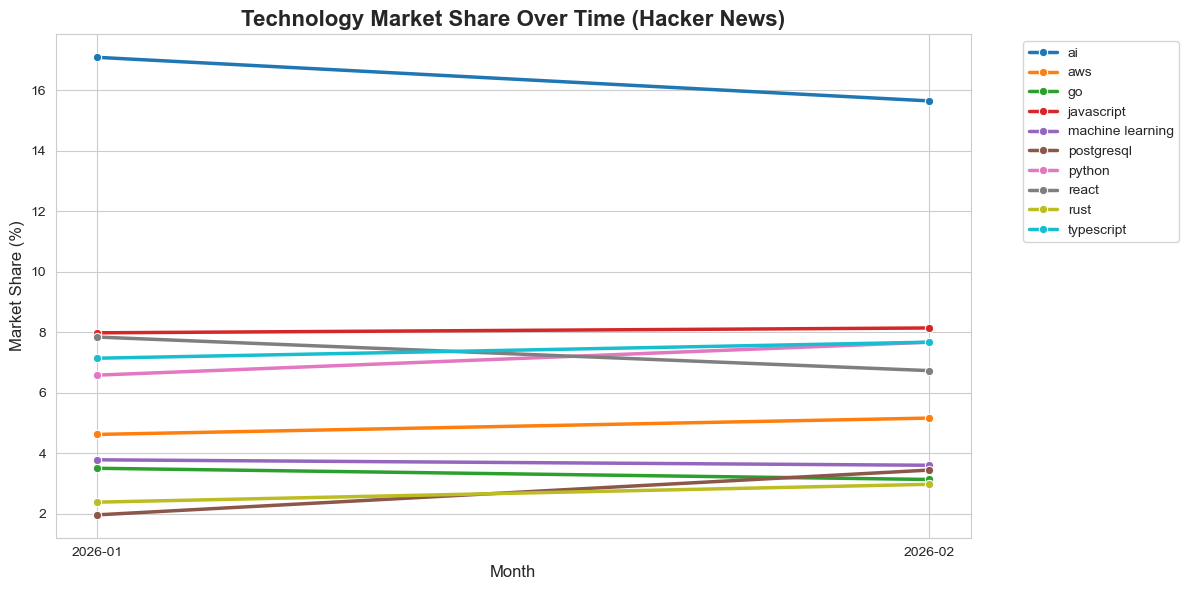

In [5]:
# Identify the Top 10 skills by total volume
top_10 = df.groupby('skills')['count'].sum().nlargest(10).index
filtered_df = df[df['skills'].isin(top_10)]

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.lineplot(data=filtered_df, x='period', y='market_share', hue='skills', marker='o', linewidth=2.5)

plt.title("Technology Market Share Over Time (Hacker News)", fontsize=16, fontweight='bold')
plt.ylabel("Market Share (%)", fontsize=12)
plt.xlabel("Month", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

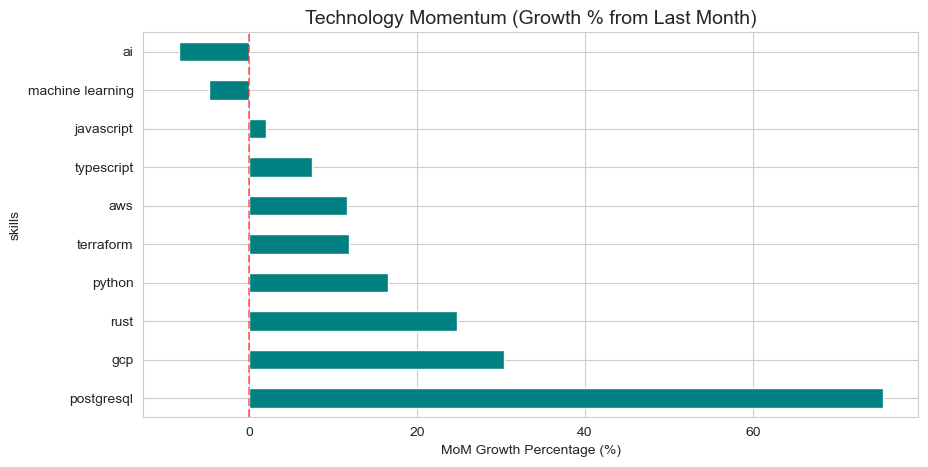

In [6]:
# Calculate % Growth MoM
growth_df = pivot_df.pct_change().fillna(0) * 100

# FILTER: Only look at tech with >1.5% market share to avoid "Small Number Bias"
established_tech = pivot_df.columns[pivot_df.iloc[-1] > 1.5]
latest_growth = growth_df[established_tech].iloc[-1].sort_values(ascending=False)

# Plotting the 'Momentum'
plt.figure(figsize=(10, 5))
latest_growth.head(10).plot(kind='barh', color='teal')
plt.title("Technology Momentum (Growth % from Last Month)", fontsize=14)
plt.xlabel("MoM Growth Percentage (%)")
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.show()